# 1. Market Data & Returns

## Objective

This notebook prepares the historical market data used throughout the Market Risk Engine.

The analysis covers five liquid ETFs representing different market exposures:

- **SPY** — U.S. large-cap equities
- **QQQ** — U.S. technology/growth equities
- **IWM** — U.S. small-cap equities
- **TLT** — long-duration U.S. Treasury bonds
- **GLD** — gold

The objective is to:

1. Obtain and inspect historical price data
2. Validate data quality
3. Handle missing observations
4. Calculate daily returns
5. Examine the statistical properties of returns
6. Assess whether a normal distribution is an appropriate representation of the data

The resulting return series are used as inputs for the volatility, portfolio construction, and VaR models developed in subsequent notebooks.

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

from project_01_market_risk_engine.src.data import download_prices

In [3]:
TICKERS = [
    "SPY",
    "QQQ",
    "IWM",
    "TLT",
    "GLD"
]

START_DATE = "2015-01-01"
END_DATE = "2026-01-01"

In [4]:
prices = download_prices(
    tickers=TICKERS,
    start=START_DATE,
    end=END_DATE
)

prices.head()

[*********************100%***********************]  5 of 5 completed


Ticker,GLD,IWM,QQQ,SPY,TLT
Date,,,,,
2015-01-02,114.080002,102.275993,94.462715,169.267487,91.566460
2015-01-05,115.800003,100.908676,93.077042,166.210556,93.004822
2015-01-06,117.120003,99.162903,91.829071,164.645081,94.680481
2015-01-07,116.430000,100.384048,93.012833,166.696716,94.493538
2015-01-08,115.940002,102.086815,94.793045,169.654800,93.242126


## Historical Price Data

Historical prices are collected for the five selected assets over the period from January 2015 through December 2025.

The resulting dataset contains **2,766 daily observations across five assets**.

In [5]:
prices.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2766 entries, 2015-01-02 to 2025-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   GLD     2766 non-null   float64
 1   IWM     2766 non-null   float64
 2   QQQ     2766 non-null   float64
 3   SPY     2766 non-null   float64
 4   TLT     2766 non-null   float64
dtypes: float64(5)
memory usage: 129.7 KB


In [6]:
prices.describe()

Ticker,GLD,IWM,QQQ,SPY,TLT
count,2766.000000,2766.000000,2766.000000,2766.000000,2766.000000
mean,165.752133,158.439439,263.978955,335.312008,98.834372
std,60.066126,41.414078,143.848931,139.639487,15.526646
min,100.500000,82.705101,89.282784,153.779709,72.833420
25%,120.902502,124.267050,137.689312,217.810303,87.941206
50%,159.375000,151.497543,241.022713,298.388947,94.267586
75%,180.630001,195.262981,358.547195,419.840691,106.483652
max,416.739990,255.207077,632.796814,685.029480,141.016541


In [7]:
prices.isna().sum()

Ticker
GLD    0
IWM    0
QQQ    0
SPY    0
TLT    0
dtype: int64

In [9]:
"""We can use linear interpolation if there are missing values in the cell above. 
Since there are currently no missing values, it will not affect anything"""

prices = prices.interpolate()

In [11]:
returns = prices.pct_change().dropna()
returns.head()

Ticker,GLD,IWM,QQQ,SPY,TLT
Date,,,,,
2015-01-05,0.015077,-0.013369,-0.014669,-0.018060,0.015708
2015-01-06,0.011399,-0.017301,-0.013408,-0.009419,0.018017
2015-01-07,-0.005891,0.012315,0.012891,0.012461,-0.001974
2015-01-08,-0.004209,0.016963,0.019139,0.017745,-0.013243
2015-01-09,0.011385,-0.009603,-0.006583,-0.008014,0.010953


In [13]:
returns.describe()

Ticker,GLD,IWM,QQQ,SPY,TLT
count,2765.000000,2765.000000,2765.000000,2765.000000,2765.000000
mean,0.000494,0.000416,0.000772,0.000564,0.000015
std,0.009290,0.014195,0.013847,0.011208,0.009474
min,-0.064269,-0.132670,-0.119788,-0.109424,-0.066684
25%,-0.004628,-0.006937,-0.005002,-0.003705,-0.005724
50%,0.000557,0.000805,0.001227,0.000637,0.000357
75%,0.005414,0.008230,0.007803,0.005925,0.005593
max,0.049038,0.091492,0.120031,0.105019,0.075196


In [16]:
returns.std()*(252**0.5)

Ticker
GLD    0.147472
IWM    0.225335
QQQ    0.219817
SPY    0.177925
TLT    0.150397
dtype: float64

## Data Quality Checks

Before using market data in a risk model, the dataset should be assessed for:

- duplicate observations
- chronological ordering
- missing values
- non-positive prices
- extreme returns
- inconsistent observations

These checks are performed before calculating risk measures. Extreme observations are not automatically removed because genuine market shocks are relevant to market-risk estimation.

In [ ]:
    """Checking for duplicate dates. Should return zero
    """
prices.index.duplicated().sum()

np.int64(0)

In [25]:
"""Checking for duplicate columns. Should return zero
""" 
prices.columns.duplicated().sum()

np.int64(0)

In [ ]:
"""Checking for monotonically increasing dates in index. Should be true
"""
prices.index.is_monotonic_increasing

True

In [21]:
"""Checking for non-positive prices. Should return zero
"""

(prices<0).sum()

Ticker
GLD    0
IWM    0
QQQ    0
SPY    0
TLT    0
dtype: int64

In [24]:
"""Checking for missing observations. Should return zero
""" 
prices.isna().sum()

Ticker
GLD    0
IWM    0
QQQ    0
SPY    0
TLT    0
dtype: int64

In [34]:
"""Checking for extreme values
"""
print(returns.abs().quantile(0.999))
print(returns.abs().quantile(0.01))

Ticker
GLD    0.048650
IWM    0.092846
QQQ    0.086354
SPY    0.091801
TLT    0.058384
Name: 0.999, dtype: float64
Ticker
GLD    0.000086
IWM    0.000186
QQQ    0.000098
SPY    0.000070
TLT    0.000082
Name: 0.01, dtype: float64


In [37]:

for ticker in returns.columns:
    print(f"5 Largest returns for ticker {ticker} ")
    print(returns[ticker].nlargest(5))
    
for ticker in returns.columns:
    print(f"5 Smallest returns for ticker {ticker} ")
    print(returns[ticker].nsmallest(5))

5 Largest returns for ticker GLD 
Date
2016-06-24    0.049038
2020-03-24    0.048530
2020-03-23    0.044180
2016-02-11    0.040189
2025-04-09    0.036991
Name: GLD, dtype: float64
5 Largest returns for ticker IWM 
Date
2020-03-24    0.091492
2025-04-09    0.085002
2020-04-06    0.076563
2020-03-13    0.066983
2020-03-26    0.062199
Name: IWM, dtype: float64
5 Largest returns for ticker QQQ 
Date
2025-04-09    0.120031
2020-03-13    0.084706
2020-03-24    0.077437
2020-03-17    0.075841
2022-11-10    0.073788
Name: QQQ, dtype: float64
5 Largest returns for ticker SPY 
Date
2025-04-09    0.105019
2020-03-24    0.090603
2020-03-13    0.085486
2020-04-06    0.067166
2020-03-26    0.058390
Name: SPY, dtype: float64
5 Largest returns for ticker TLT 
Date
2020-03-20    0.075196
2020-03-16    0.064766
2020-03-06    0.052044
2020-03-23    0.041208
2022-11-10    0.038473
Name: TLT, dtype: float64
5 Smallest returns for ticker GLD 
Date
2025-10-21   -0.064269
2020-08-11   -0.053694
2020-11-09   -

In [30]:
returns.nlargest(5, columns=returns.columns)

Ticker,GLD,IWM,QQQ,SPY,TLT
Date,,,,,
2016-06-24,0.049038,-0.038007,-0.041188,-0.035909,0.026847
2020-03-24,0.048530,0.091492,0.077437,0.090603,-0.018614
2020-03-23,0.044180,-0.014793,0.000722,-0.025568,0.041208
2016-02-11,0.040189,-0.010852,-0.001448,-0.013009,0.007003
2025-04-09,0.036991,0.085002,0.120031,0.105019,0.005886


### Data Quality Results

The dataset passes the primary structural data-quality checks:

- No duplicate dates
- No duplicate columns
- Chronologically ordered observations
- No missing price observations
- No non-positive prices

The return series also contains substantial historical market movements, including large observations during periods of market stress. These observations are retained for subsequent risk estimation.

## Return Distribution Analysis

Daily returns are examined to understand their statistical characteristics before applying parametric risk models.

Three properties are of particular interest:

- **Skewness** — measures asymmetry in the return distribution
- **Kurtosis** — captures the presence of fat tails and extreme observations
- **Normality** — determines whether a normal-distribution assumption is reasonable

These characteristics are important for VaR modeling because parametric VaR typically relies on distributional assumptions that may not adequately capture observed market tails.

In [38]:
returns.skew()

Ticker
GLD   -0.177899
IWM   -0.490116
QQQ   -0.193344
SPY   -0.311941
TLT    0.091390
dtype: float64

In [39]:
returns.kurtosis()

Ticker
GLD     3.207635
IWM     7.804521
QQQ     7.641112
SPY    14.164242
TLT     4.498204
dtype: float64

In [40]:
returns.quantile([0.01, 0.05, 0.50, 0.95, 0.99])

Ticker,GLD,IWM,QQQ,SPY,TLT
0.01,-0.023987,-0.036385,-0.039037,-0.032156,-0.023027
0.05,-0.014655,-0.021061,-0.022612,-0.016744,-0.015066
0.50,0.000557,0.000805,0.001227,0.000637,0.000357
0.95,0.015405,0.021798,0.020865,0.015594,0.014741
0.99,0.024123,0.035378,0.034383,0.026255,0.023750


### Empirical Returns vs. Normal Distribution

The empirical return distributions are compared with fitted normal distributions using the same historical mean and standard deviation.

This comparison provides a visual assessment of whether the normal distribution adequately represents the observed return behavior, particularly in the tails.

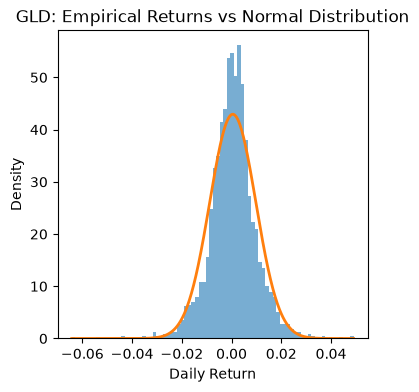

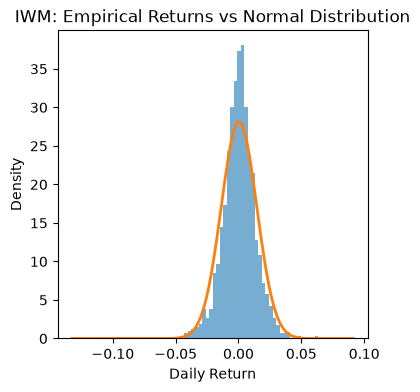

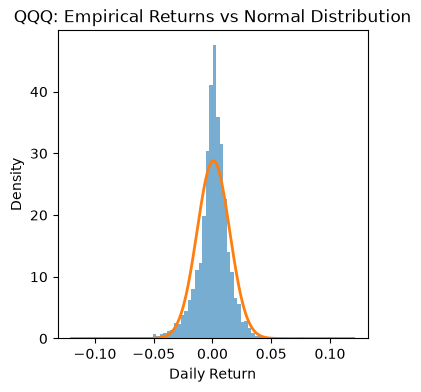

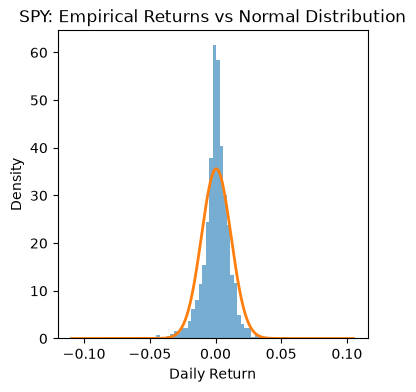

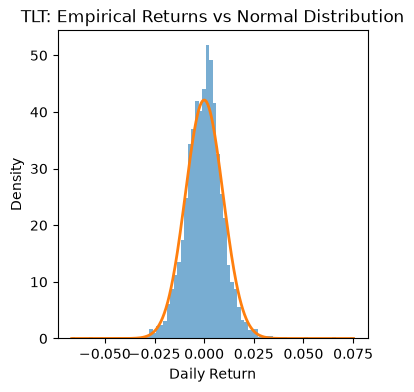

In [50]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

for ticker in returns.columns:
    mu = returns[ticker].mean()
    sigma = returns[ticker].std()
    
    x = np.linspace(
        start=returns[ticker].min(),
        stop = returns[ticker].max(),
        num = 500
    )
    
    normal_density = norm.pdf(x, mu, sigma)
    
    plt.figure(figsize=(4, 4))

    plt.hist(
        returns[ticker],
        bins=80,
        density=True,
        alpha=0.6
    )

    plt.plot(
        x,
        normal_density,
        linewidth=2
    )

    plt.title(f"{ticker}: Empirical Returns vs Normal Distribution")
    plt.xlabel("Daily Return")
    plt.ylabel("Density")

    plt.show()
    

### Jarque–Bera Normality Test

The Jarque–Bera test evaluates whether the observed returns are consistent with a normal distribution based on skewness and kurtosis.

**Null hypothesis:** returns are normally distributed.

A small p-value provides evidence against the normality assumption.

In [51]:
"""Statistical Test"""

from scipy.stats import jarque_bera

for ticker in returns.columns:
    statistic, p_value = jarque_bera(returns[ticker])
    print(
        f"{ticker}: "
        f"JB Statistic = {statistic:.3f}, "
        f"p-value = {p_value:.6g}"
    )

GLD: JB Statistic = 1194.058, p-value = 5.17202e-260
IWM: JB Statistic = 7098.745, p-value = 0
QQQ: JB Statistic = 6715.726, p-value = 0
SPY: JB Statistic = 23068.009, p-value = 0
TLT: JB Statistic = 2324.289, p-value = 0


## Key Observations

The historical dataset contains **2,766 daily observations** for each of the five selected assets, with no missing price observations.

The return distributions exhibit meaningful departures from normality. In particular, several assets display elevated kurtosis, indicating heavier tails than would be expected under a normal distribution.

The Jarque–Bera test strongly rejects the null hypothesis of normally distributed returns for all five assets.

These results suggest that a normality assumption may not fully capture the tail behavior of the return series. This motivates the use of multiple VaR approaches in the subsequent notebooks:

- **Historical VaR** — uses the empirical distribution directly
- **Parametric VaR** — evaluates the impact of a distributional assumption
- **Monte Carlo VaR** — estimates portfolio losses through simulation

The comparison of these approaches provides a more robust assessment of portfolio market risk.